It is crucial that you thoroughly read the tutorial before starting this challenge. For the first part we will closely follow <a href="https://arxiv.org/abs/2002.11217">M. Khezri et al. Anneal-path correction in flux qubits</a> Suplementary material section 3.

In [60]:
# import all necessary libraries (feel free to add more if you need them)
import cas
import scipy
import numpy as np

## Part 1 - Exploring the qubit space

#### Qubit definition
The first step is to create a qubit object. We will be using the CAS code for that. We will take the parameters given by <a href="https://arxiv.org/abs/2103.06461">M. Khezri et al. Customized quantum annealing schedules</a>

In [61]:
i_c = 242; c_shunt = 62; c_z = 4.85; lq = 480; alpha = 0.4; d = 0
# create a qubit
qubit = cas.CSFQ(i_c, c_shunt, c_z, lq, alpha, d)

/Users/JFAMcBookPro/opt/anaconda3/envs/haqtoberfest/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


#### Exercise 1:
You can get the hamiltonian with `qubit.get_h(phi_x, phi_z)`. Do a sweep on a reasonable range of $\Phi_x$, $Phi_z$ and plot the energy gap of the ground and excited levels of the qubits for that range. You should obtain a figure like the following:

In [ ]:
# Create Sweep range for phix and phiz
# based on similar graph from paper (-3 pi, 3 pi)
Nx = 251
Nz = 251
phix = np.linspace(-3*np.pi, 3*np.pi, Nx)
phiz = np.linspace(-3*np.pi, 3*np.pi, Nz)

# sample H, to get dimensions of system. I don't know where does it come from... H = NxN
N = np.size( qubit.get_h(0., 0.) , 0)

E0 = np.empty((Nx,Nz), dtype=np.float64)
E1 = np.empty((Nx,Nz), dtype=np.float64)
eigen0 = np.empty((Nx,Nz,N,), dtype=np.complex128)
eigen1 = np.empty((Nx,Nz,N,), dtype=np.complex128)

delta = np.empty((Nx,Nz), dtype=np.float64)

In [82]:
# Create Sweep range for phix and phiz
# based on similar graph from paper (-3 pi, 3 pi)
Nx = 251
Nz = 251
phix = np.linspace(-3*np.pi, 3*np.pi, Nx)
phiz = np.linspace(-3*np.pi, 3*np.pi, Nz)

# sample H, to get dimensions of system. I don't know where does it come from... H = NxN
N = np.size( qubit.get_h(0., 0.) , 0)

E0 = np.empty((Nx,Nz), dtype=np.float64)
E1 = np.empty((Nx,Nz), dtype=np.float64)
eigen0 = np.empty((Nx,Nz,N,), dtype=np.complex128)
eigen1 = np.empty((Nx,Nz,N,), dtype=np.complex128)

delta = np.empty((Nx,Nz), dtype=np.float64)

for i in range(Nx):
    for j in range(Nz):
        # Generate hamiltonian for given bias
        H = qubit.get_h(phix[i], phiz[j])

        # Calculate first two eigenvalues and eigenvectors
        eigenvals, eigenvec = scipy.sparse.linalg.eigsh( H, k=2, which="SR")

        # Eigenvec: v[:,i] represents ith eigenvector corresponding to eigenval[i]

        E0[i,j] = eigenvals[0]
        E1[i,j] = eigenvals[1]
        eigen0[i,j] = eigenvec[:,0]
        eigen1[i,j] = eigenvec[:,1]

        delta[i,j] = E1[i,j] - E0[i,j]

    print(i/Nx*100, " %") # progress bar


0.0  %
0.398406374501992  %
0.796812749003984  %
1.1952191235059761  %
1.593625498007968  %
1.9920318725099602  %
2.3904382470119523  %
2.788844621513944  %
3.187250996015936  %
3.5856573705179287  %
3.9840637450199203  %
4.382470119521913  %
4.780876494023905  %
5.179282868525896  %
5.577689243027888  %
5.9760956175298805  %
6.374501992031872  %
6.772908366533864  %
7.171314741035857  %
7.569721115537849  %
7.968127490039841  %
8.366533864541832  %
8.764940239043826  %
9.163346613545817  %
9.56175298804781  %
9.9601593625498  %
10.358565737051793  %
10.756972111553784  %
11.155378486055776  %
11.553784860557768  %
11.952191235059761  %
12.350597609561753  %
12.749003984063744  %
13.147410358565736  %
13.545816733067728  %
13.94422310756972  %
14.342629482071715  %
14.741035856573706  %
15.139442231075698  %
15.53784860557769  %
15.936254980079681  %
16.334661354581673  %
16.733067729083665  %
17.131474103585656  %
17.52988047808765  %
17.928286852589643  %
18.326693227091635  %
18.725

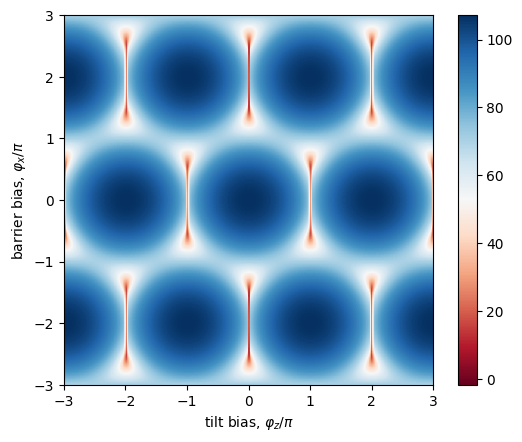

In [83]:
import matplotlib.pyplot as plt

X, Y = np.meshgrid(phix/np.pi, phiz/np.pi)

#plt.contourf(X, Y, delta, 10000, cmap='RdBu')
plt.imshow(delta, cmap='RdBu', extent=[-3,3,-3,3])

# row is phix, so in image this is vertical coordinate y
# column is phiy, so in image this is horizontal coordinate x
plt.xlabel(r'tilt bias, $\varphi_z/\pi$')
plt.ylabel(r'barrier bias, $\varphi_x/\pi$')
plt.colorbar()
plt.show()

#### Exercise 2:
The persistent current operator is defined as $$\hat{I_p} = \frac{\partial H(\Phi_x, \Phi_z)}{\partial \Phi_z}$$
Calculate $I_p^{low}$ as defined in Khezri's paper (suplementary note 3). Then plot the first and second eigvenvalues of the persistent current to identify the valid anneal regions.

In [120]:
# We may iterate over a similar set 

####


#####

Iplow0 = np.empty((Nx,Nz), dtype=np.float64)
Iplow1 = np.empty((Nx,Nz), dtype=np.float64)
eigen0I = np.empty((Nx,Nz,2,), dtype=np.complex128)
eigen1I = np.empty((Nx,Nz,2,), dtype=np.complex128)

sigmaxI = np.empty((Nx,Nz,), dtype=np.float64)
sigmazI = np.empty((Nx,Nz,), dtype=np.float64)

for i in range(0,Nx):
    for j in range(0,Nz):
        Ip = qubit.get_ip(phix[i], phiz[j])
        g_vec = eigen0[i, j]
        e_vec = eigen1[i, j]

        I00 = np.dot(np.conj(g_vec), (Ip@g_vec))
        I10 = np.dot(np.conj(e_vec), (Ip@g_vec))
        I01 = np.dot(np.conj(g_vec), (Ip@e_vec))
        I11 = np.dot(np.conj(e_vec), (Ip@e_vec))

        Iplow = np.array([[I00, I01],[I10, I11]])


        eigenvalsI, eigenvecI = scipy.sparse.linalg.eigs(Iplow, k=2, which="SR")
        Iplow0[i,j] = eigenvalsI[0]
        Iplow1[i,j] = eigenvalsI[1]

        #eigen0I[i,j] = eigenvecI[:,0]
        #eigen1I[i,j] = eigenvecI[:,1]

        eign_v = np.array([eigen0[i,j], eigen1[i,j]]).T
        #eign_v[:, 0] = eigen0[i,j]
        #eign_v[:, 1] = eigen1[i,j]
        eign_e = np.array([E0[i,j], E1[i,j]])
        u_vec = eigenvecI


        # Remove sigma y by adding phase
        u_vec[:, 0] = u_vec[:, 0] * abs(u_vec[:, 0][0]) / u_vec[:, 0][0]
        u_vec[:, 1] = u_vec[:, 1] * abs(u_vec[:, 1][0]) / u_vec[:, 1][0]


        h_eff = u_vec.conj().T.dot(np.diag(eign_e[0:2])).dot(u_vec)
        h_eff = (h_eff + h_eff.T.conj()) / 2  # assure hermitianity

        sigma_x = ((h_eff[0, 1] + h_eff[1, 0]) / 2)
        sigma_z = ((h_eff[0, 0] - h_eff[1, 1]) / 2)

        # Make sigma_x coefficient always positive
        if sigma_x < 0:
            u_vec[:, 0] = -u_vec[:, 0]
            sigma_x = -sigma_x

        #ising = np.array([sigma_x, sigma_z])
        basis = eign_v.dot(u_vec)


        eigen0I[i,j] = basis[0]#eigenvecI[:,0]
        eigen1I[i,j] = basis[1]#eigenvecI[:,1]

        sigmaxI[i,j] = sigma_x
        sigmazI[i,j] = sigma_z
        
        #print("{:.6f} {:.6f}\n{:.6f} {:.6f}\n".format(I00, I01, I10, I11))
    print(i/Nx*100, " %")


/var/folders/np/8bzvsqnd1sx6gzkksyybl9zr0000gn/T/ipykernel_1943/2403901892.py:30: RuntimeWarning: k >= N - 1 for N * N square matrix. Attempting to use scipy.linalg.eig instead.
  eigenvalsI, eigenvecI = scipy.sparse.linalg.eigs(Iplow, k=2, which="SR")
/var/folders/np/8bzvsqnd1sx6gzkksyybl9zr0000gn/T/ipykernel_1943/2403901892.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  Iplow0[i,j] = eigenvalsI[0]
/var/folders/np/8bzvsqnd1sx6gzkksyybl9zr0000gn/T/ipykernel_1943/2403901892.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  Iplow1[i,j] = eigenvalsI[1]


0.0  %
0.398406374501992  %
0.796812749003984  %
1.1952191235059761  %
1.593625498007968  %
1.9920318725099602  %
2.3904382470119523  %
2.788844621513944  %
3.187250996015936  %
3.5856573705179287  %
3.9840637450199203  %
4.382470119521913  %
4.780876494023905  %
5.179282868525896  %
5.577689243027888  %
5.9760956175298805  %
6.374501992031872  %
6.772908366533864  %
7.171314741035857  %
7.569721115537849  %
7.968127490039841  %
8.366533864541832  %
8.764940239043826  %
9.163346613545817  %
9.56175298804781  %
9.9601593625498  %
10.358565737051793  %
10.756972111553784  %
11.155378486055776  %
11.553784860557768  %
11.952191235059761  %
12.350597609561753  %
12.749003984063744  %
13.147410358565736  %
13.545816733067728  %
13.94422310756972  %
14.342629482071715  %
14.741035856573706  %
15.139442231075698  %
15.53784860557769  %
15.936254980079681  %
16.334661354581673  %
16.733067729083665  %
17.131474103585656  %
17.52988047808765  %
17.928286852589643  %
18.326693227091635  %
18.725

In [118]:
Iplow0 <= Iplow1

array([[False,  True, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

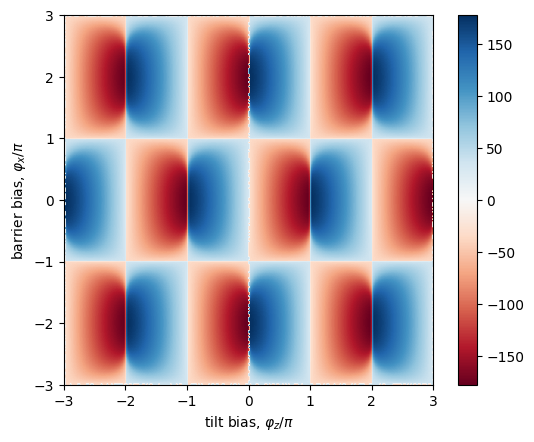

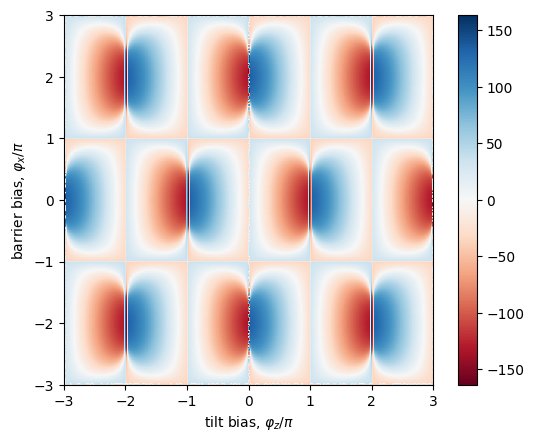

In [121]:
X, Y = np.meshgrid(phix/np.pi, phiz/np.pi)

#plt.contourf(X, Y, delta, 10000, cmap='RdBu')
plt.imshow(Iplow0, cmap='RdBu', extent=[-3,3,-3,3])

# row is phix, so in image this is vertical coordinate y
# column is phiy, so in image this is horizontal coordinate x
plt.xlabel(r'tilt bias, $\varphi_z/\pi$')
plt.ylabel(r'barrier bias, $\varphi_x/\pi$')
plt.colorbar()
plt.show()


#plt.contourf(X, Y, delta, 10000, cmap='RdBu')
plt.imshow(Iplow1, cmap='RdBu', extent=[-3,3,-3,3])

# row is phix, so in image this is vertical coordinate y
# column is phiy, so in image this is horizontal coordinate x
plt.xlabel(r'tilt bias, $\varphi_z/\pi$')
plt.ylabel(r'barrier bias, $\varphi_x/\pi$')
plt.colorbar()
plt.show()

#### Exercise 3:
Still following the same section from Khezri's paper, now calculate the values for the ising coefficients of the effective hamiltonian. Pay special attention to the contraints applied so that $H_{eff}$ can be expressed solely in terms of $\sigma_x$ and $\sigma_y$

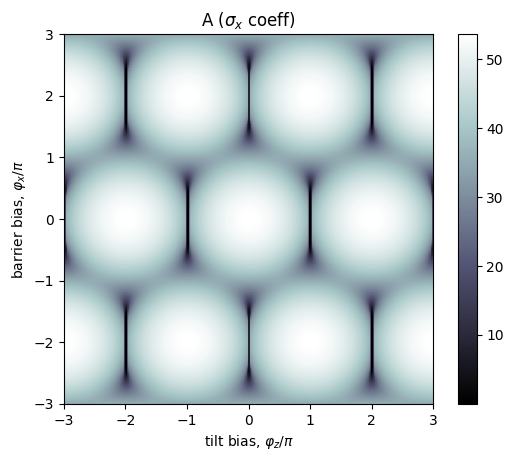

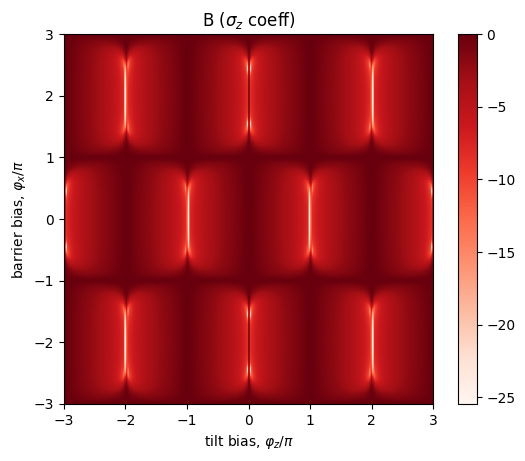

In [130]:
X, Y = np.meshgrid(phix/np.pi, phiz/np.pi)

#plt.contourf(X, Y, delta, 10000, cmap='RdBu')
plt.imshow(sigmaxI, cmap='bone', extent=[-3,3,-3,3])

# row is phix, so in image this is vertical coordinate y
# column is phiy, so in image this is horizontal coordinate x
plt.title(r"A ($\sigma_x$ coeff)")
plt.xlabel(r'tilt bias, $\varphi_z/\pi$')
plt.ylabel(r'barrier bias, $\varphi_x/\pi$')
plt.colorbar()
plt.show()


#plt.contourf(X, Y, delta, 10000, cmap='RdBu')
plt.imshow(sigmazI, cmap='Reds', extent=[-3,3,-3,3])

# row is phix, so in image this is vertical coordinate y
# column is phiy, so in image this is horizontal coordinate x
plt.title(r'B ($\sigma_z$ coeff)')
plt.xlabel(r'tilt bias, $\varphi_z/\pi$')
plt.ylabel(r'barrier bias, $\varphi_x/\pi$')
plt.colorbar()
plt.show()

In [131]:
# now for real
# Create Sweep range for phix and phiz
# based on similar graph from paper (-3 pi, 3 pi)
Nxbis = 51
Nzbis = 51
phixbis = np.linspace(0., 2*np.pi, Nxbis)
phizbis = np.linspace(0., 2*np.pi, Nzbis)
    
sigmaxI = np.empty((Nx,Nz,), dtype=np.float64)
sigmazI = np.empty((Nx,Nz,), dtype=np.float64)

# sample H, to get dimensions of system. I don't know where does it come from... H = NxN
N = np.size( qubit.get_h(0., 0.) , 0)


for i in range(Nxbis):
    for j in range(Nzbis):
        
        ISING, BASIS = qubit.get_ising(phixbis[i], phizbis[j])
        




ValueError: dimension mismatch

## Part 2 - Quantum annealing

A very common quantum gate is the <a href="https://en.wikipedia.org/wiki/Quantum_logic_gate">Hadamard gate</a>. This gate can be used to move a qubit in an eigenstate of the $\sigma_z$ basis (the basis in which we typically measure the qubit for gate based computing) to an equal superposition of the basis' eigenstates. Feel free to do the calculation by yourself by seeing how the gate matrix acts on either the $|0\rangle$ or the $|1\rangle$ states.

#### Exercise 1
What could be the initial and final hamiltonians of an annealing algorithm to perform a Hadamard gate on an analog quantum computer?

#### Exercise 2
Design an annealing schedule for the hamiltonians above. Find appropiate values of $\Delta$ and $\varepsilon$ within the annealing region from your findings in Part 1. Do not worry too much about adiabaticity here, this will be tackled in the next section.

#### Exercise 3

Find a schedule for the analog Hadamard gate which fulfills adiabaticity

## Part 3 - Open challenge

#### Exercise 1
Given the analog algorithm for the Hadamard gate, optimize it so that the schedule total time is minimal while still fulfilling adiabaticity.

#### Exercise 2
Explore the same problem for a 2 qubit gate of your choice. You can find examples on how to create coupled systems on the <a href="https://github.com/USCqserver/CAS/blob/master/docs/examples/multi_qubit_schedules.ipynb">CAS repository</a>

